In [1]:
import pandas as pd
import yfinance as yf


In [3]:
from datetime import datetime
ticker="NESTLEIND.NS"
start_date="2010-01-01"
end_date = datetime.today().strftime('%Y-%m-%d')
data = yf.download(ticker, start=start_date, end=end_date)
data.head


[*********************100%***********************]  1 of 1 completed


<bound method NDFrame.head of Price             Close         High          Low         Open       Volume
Ticker     NESTLEIND.NS NESTLEIND.NS NESTLEIND.NS NESTLEIND.NS NESTLEIND.NS
Date                                                                       
2010-01-04   433.382935   433.382935   433.382935   433.382935            0
2010-01-05   433.382935   433.382935   433.382935   433.382935            0
2010-01-06   433.382935   433.382935   433.382935   433.382935            0
2010-01-07   433.382935   433.382935   433.382935   433.382935            0
2010-01-08   102.565102   105.868615   101.765437   105.046335        12960
...                 ...          ...          ...          ...          ...
2026-08-14  1499.099976  1515.800049  1496.099976  1506.900024      1500577
2026-08-17  1470.000000  1503.699951  1468.500000  1500.000000      1721057
2026-08-18  1462.500000  1479.800049  1453.000000  1478.000000      1815216
2026-08-19  1465.000000  1481.300049  1457.099976  1462.40

In [4]:
data.to_csv("NESTLEIND_data.csv")

In [5]:
data[['Open','High','Low','Close','Volume']].describe()

Price,Open,High,Low,Close,Volume
Ticker,NESTLEIND.NS,NESTLEIND.NS,NESTLEIND.NS,NESTLEIND.NS,NESTLEIND.NS
count,4109.000000,4109.000000,4109.000000,4109.000000,4.109000e+03
mean,577.807661,583.578981,571.510702,577.491209,1.222697e+06
std,401.124201,404.555271,397.203677,400.937964,1.338188e+06
min,95.067040,103.401784,95.067040,102.347191,0.000000e+00
25%,220.989582,224.052412,218.750646,220.649170,4.627600e+05
50%,411.294174,416.444818,407.246226,410.711395,9.049600e+05
75%,913.942841,920.698687,905.046294,913.910156,1.519780e+06
max,1534.099976,1553.000000,1520.000000,1540.000000,2.294119e+07


In [6]:
data.index = pd.to_datetime(data.index)

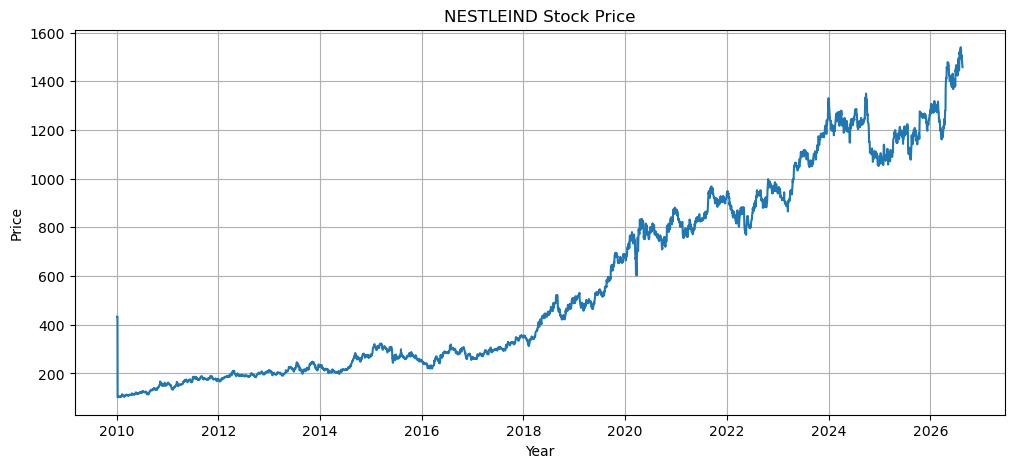

In [7]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

ts = data['Close']

plt.figure(figsize=(12,5))
plt.plot(ts)

# Show ticks every 2 years (you can change to 1, 3, etc.)
plt.gca().xaxis.set_major_locator(mdates.YearLocator(2))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.title("NESTLEIND Stock Price")
plt.xlabel("Year")
plt.ylabel("Price")
plt.grid()

plt.show()


In [8]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(ts.dropna())

print("ADF Statistic:", result[0])
print("p-value:", result[1])
print("Critical Values:")
for key, value in result[4].items():
    print(key, ":", value)


ADF Statistic: 0.5888417865779977
p-value: 0.9873373448020758
Critical Values:
1% : -3.431948291374147
5% : -2.862246237563578
10% : -2.567145937011734


In [9]:
import numpy as np

ts_log = np.log(ts)
ts_log_diff = ts_log.diff().dropna()


In [10]:
result = adfuller(ts_log_diff.dropna())

print("ADF Statistic:", result[0])
print("p-value:", result[1])
print("Critical Values:")
for key, value in result[4].items():
    print(key, ":", value)


ADF Statistic: -64.32198184132248
p-value: 0.0
Critical Values:
1% : -3.431943229091185
5% : -2.8622440012896564
10% : -2.5671447465191686


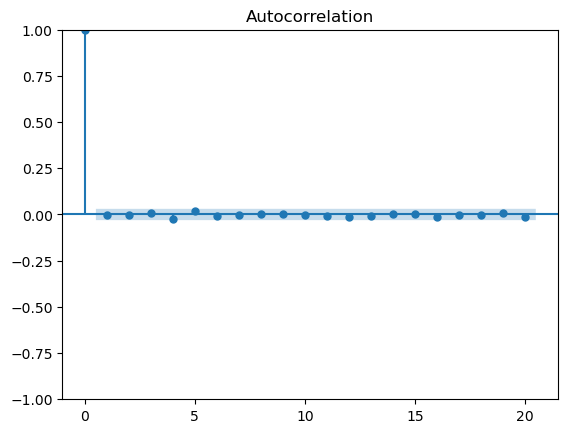

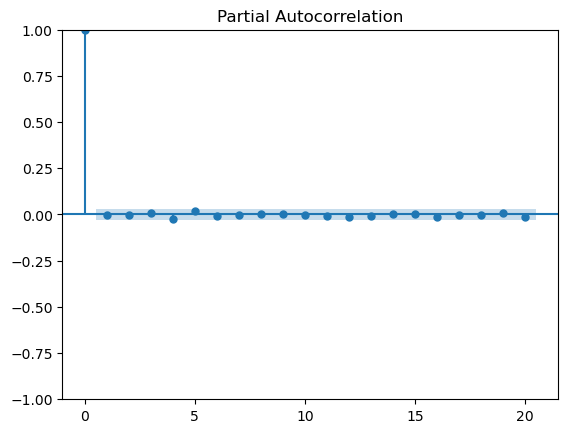

In [11]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt
diff=ts_log_diff
plot_acf(diff, lags=20)
plot_pacf(diff, lags=20)

plt.show()
